# Snapshot eval violins - RL vs rule-based control

Per-episode eval metrics of one or more snapshots, **one violin per eval CSV**. Compared here:
SAC, PPO and DreamerV3 trained on the `sta_lin_battery_only_price` trial (static linear battery,
dynamic day-ahead prices), plus SAC/PPO re-runs at gamma 0.99 instead of the trial's 0.997,
against the rule-based baselines of the `rbc_base` snapshot.

`SNAPSHOTS` (next cell) lists the snapshots; each entry selects which eval kinds are read:

| Struct key | Run directory | Producer | CSVs picked up |
|---|---|---|---|
| `eval-ray` | `runs/eval_<ts>/` | Ray RLlib eval (`run_eval_ray.py`) | `eval_results/*_eval/eval_*.csv` |
| `eval-sb` | `runs/eval_sb_<ts>/` | SB3 eval (`run_eval_sb.py`) | `eval_results/*_eval/eval_*.csv` |
| `eval-rbc` | `runs/eval_rbc_<ts>/` | Rule-based eval (`run_eval_rule_based.py`) | `eval_results/*_rule_based/<strategy>/episodes.csv` |

Violins are labelled by rule-based strategy name or by RL algorithm (read from the sidecar JSON
next to each RL eval CSV); with several snapshots the label also carries the entry's 1-based
index in `SNAPSHOTS`, e.g. `sac (ray) (2)`.

Three figures - `total_reward`, `cum_E_kWh` and `cum_price_EUR` - are exported as
`<date>_<time>_out_<i>.pdf` next to this notebook. Requested eval kinds without CSVs are
reported by the **last cell**.

**Main input:** set `SNAPSHOTS` in the next cell.

In [27]:
# --- Main input: the snapshots to analyse (paths absolute, or relative to the repo root).
# Each entry selects which eval kinds are picked up (missing keys default to True).
# When several snapshots are plotted, violin labels carry the entry's 1-based index, e.g. "sac (ray) (2)";
# the figure title maps each index to the snapshot's "tag" (optional key, defaults to the
# snapshot's leading YYYYmmdd_HHMMSS timestamp).
SNAPSHOTS = [
    {"path": "snapshots/20260703_004926_sta_lin_battery_only_price_sac", "eval-ray": True, "eval-sb": True, "eval-rbc": False},
    # {"path": "snapshots/20260704_215559_sta_lin_battery_only_price_sac_gam099", "eval-ray": True, "eval-sb": False, "eval-rbc": False},
    {"path": "snapshots/20260704_144904_sta_lin_battery_only_price_ppo", "eval-ray": True, "eval-sb": False, "eval-rbc": False},
    # {"path": "snapshots/20260704_215614_sta_lin_battery_only_price_ppo_gam099", "eval-ray": True, "eval-sb": False, "eval-rbc": False},
    # {"path": "snapshots/20260704_183007_sta_lin_battery_only_price_dreamerv3", "eval-ray": True, "eval-sb": False, "eval-rbc": False},
    {"path": "snapshots/20260704_183007_sta_lin_battery_only_price_dreamerv3_lo_tr", "eval-ray": True, "eval-sb": False, "eval-rbc": False},
    # {"path": "snapshots/20260704_183007_sta_lin_battery_only_price_dreamerv3_default", "eval-ray": True, "eval-sb": False, "eval-rbc": False},
    # {"path": "snapshots/20260705_153845_sta_lin_battery_only_price_sac_short_rfl", "eval-ray": True, "eval-sb": False, "eval-rbc": False}
    {"path": "snapshots/20260705_234931_sta_lin_battery_only_price_rbc_base", "eval-ray": False, "eval-sb": False, "eval-rbc": True},
    # {"path": "snapshots/20260705_234931_sta_lin_battery_only_price_rbc_base_v2", "eval-ray": False, "eval-sb": False, "eval-rbc": True}
]


In [28]:
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

EVAL_KINDS = ("eval-ray", "eval-sb", "eval-rbc")


def _find_repo_root() -> Path:
    """Walk upwards from the cwd until the directory containing snapshots/ is found,
    so the notebook runs both from docs/ and from the repo root."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "snapshots").is_dir():
            return candidate
    raise FileNotFoundError("No 'snapshots/' directory found upwards of the cwd — run inside the repo.")


REPO_ROOT = _find_repo_root()


def _default_tag(snapshot_dir: Path) -> str:
    """Leading YYYYmmdd_HHMMSS timestamp of the snapshot name — unique and short enough for the title."""
    match = re.match(r"\d{8}_\d{6}", snapshot_dir.name)
    return match.group(0) if match else snapshot_dir.name


snapshot_specs: list[dict] = []
for index, entry in enumerate(SNAPSHOTS, start=1):
    snapshot_dir = Path(entry["path"])
    snapshot_dir = snapshot_dir if snapshot_dir.is_absolute() else REPO_ROOT / snapshot_dir
    if not snapshot_dir.is_dir():
        raise FileNotFoundError(f"Snapshot directory not found: {snapshot_dir}")
    snapshot_specs.append(
        {
            "index": index,
            "dir": snapshot_dir,
            "tag": entry.get("tag", _default_tag(snapshot_dir)),
            **{kind: bool(entry.get(kind, True)) for kind in EVAL_KINDS},
        }
    )

if not snapshot_specs:
    raise ValueError("SNAPSHOTS is empty — add at least one snapshot entry.")

MULTI_SNAPSHOT = len(snapshot_specs) > 1  # single-snapshot runs keep the plain labels and PDF names

for spec in snapshot_specs:
    requested = ", ".join(kind for kind in EVAL_KINDS if spec[kind])
    print(f"Snapshot ({spec['index']}): {spec['dir']}  [{requested or 'nothing requested'}]")
    print(f"              PDF output → {spec['dir'] / 'stat'}")

Snapshot (1): /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260703_004926_sta_lin_battery_only_price_sac  [eval-ray, eval-sb]
              PDF output → /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260703_004926_sta_lin_battery_only_price_sac/stat
Snapshot (2): /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_144904_sta_lin_battery_only_price_ppo  [eval-ray]
              PDF output → /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_144904_sta_lin_battery_only_price_ppo/stat
Snapshot (3): /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_183007_sta_lin_battery_only_price_dreamerv3_lo_tr  [eval-ray]
              PDF output → /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_183007_sta_lin_battery_only_price_dreamerv3_lo_tr/stat
Snapshot (4): /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260705_234931_sta_lin_battery_only_price_rbc_base  [eval-rbc]
              PDF output → /hkfs/home/haicore/ia

## Output naming

Everything saved here lands next to the notebook as `<date>_<time>_out_<i>.<file format>`:
one timestamp per notebook run, `out_index` counting up per saved artefact, so no run
overwrites an earlier one.

In [29]:
from datetime import datetime
from pathlib import Path

# VS Code exposes the notebook path; a plain Jupyter kernel starts in the notebook's directory.
OUT_DIR = Path(globals()["__vsc_ipynb_file__"]).parent if "__vsc_ipynb_file__" in globals() else Path.cwd()
OUT_RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
out_index = 0  # incremented once per saved artefact; reset by re-running this cell


def next_out_path(file_format: str) -> Path:
    """Next '<date>_<time>_out_<i>.<file_format>' path in this notebook's directory."""
    global out_index
    out_index += 1
    return OUT_DIR / f"{OUT_RUN_STAMP}_out_{out_index}.{file_format}"


## Discover the eval CSVs

One record per CSV, restricted to the eval kinds each `SNAPSHOTS` entry requests. RL CSVs take
their violin name from the `algorithm` field of the sidecar JSON with the same stem
(e.g. `eval_checkpoint_000174_….json`), rule-based ones from their strategy directory;
`pv_surplus_charge` is dropped entirely. Labels that would collide (e.g. two checkpoints of one
algorithm) get a distinguishing suffix.

Seed-sweep run directories (`…_seed<N>`) are skipped so a sweep never leaks into this
comparison - **except** when that would leave a requested eval kind with no CSVs at all: the
DreamerV3 snapshot was only ever evaluated as a sweep, so it falls back to its base-seed
(`_seed42`) run, which matches the seed and episode count of the other snapshots' plain runs.
Such a fallback prints a `note:` line.

Kinds still empty after that fallback are collected in `missing_eval_logs` and reported by the
last cell.

In [30]:
METRICS = ("total_reward", "cum_E_kWh", "cum_price_EUR")

# Rule-based strategy directories to leave out of the figures entirely
EXCLUDED_STRATEGIES = {"pv_surplus_charge"}

# Seed-sweep run directories (produced by submit_snapshot_eval_seeds.sh, e.g.
# "eval_20260706_120000_seed42") feed the companion snapshot_eval_violins_seeds.ipynb —
# exclude them here so a seed sweep never leaks into the main comparison.
SEED_SWEEP_DIR_REGEX = re.compile(r"_seed-?\d+$")

# Some snapshots (e.g. the dreamerv3 one) were only ever evaluated as a seed sweep and have no
# plain runs/eval_<ts>/ directory, so the exclusion above would drop them from the comparison
# entirely. Their base-seed sweep run is the exact equivalent of a plain eval run — same seed 42
# that the other snapshots' plain runs used, same checkpoint, same episode count — so it stands in
# whenever a requested eval kind would otherwise be empty.
BASE_SEED_DIR_REGEX = re.compile(r"_seed-?42$")

# Requested-but-absent eval kinds, filled during discovery; the last notebook cell reports these.
missing_eval_logs: list[str] = []


def _sanitise_label(name: str) -> str:
    """Underscores read poorly on the x-axis — display labels use spaces instead."""
    return name.replace("_", " ")


def _algorithm_from_sidecar_json(csv_path: Path) -> str | None:
    sidecar = csv_path.with_suffix(".json")
    if not sidecar.is_file():
        return None
    try:
        return json.loads(sidecar.read_text()).get("algorithm")
    except (json.JSONDecodeError, OSError):
        return None


def _rl_eval_records(run_dir: Path, kind: str) -> list[dict]:
    records = []
    for csv_path in sorted(run_dir.glob("eval_results/*_eval/eval_*.csv")):
        algorithm = _algorithm_from_sidecar_json(csv_path) or "unknown"
        records.append({"label": f"{_sanitise_label(algorithm)} ({kind})", "kind": kind, "csv": csv_path})
    return records


def _rule_based_records(run_dir: Path) -> list[dict]:
    records = []
    for csv_path in sorted(run_dir.glob("eval_results/*_rule_based/*/episodes.csv")):
        if csv_path.parent.name in EXCLUDED_STRATEGIES:
            continue
        records.append({"label": _sanitise_label(csv_path.parent.name), "kind": "rule-based", "csv": csv_path})
    return records


def _records_for_kind(run_dir: Path, eval_kind: str) -> list[dict]:
    """Records of the one run directory `run_dir`, read according to its eval kind."""
    if eval_kind == "eval-rbc":
        return _rule_based_records(run_dir)
    return _rl_eval_records(run_dir, "sb3" if eval_kind == "eval-sb" else "ray")


def _run_dir_eval_kind(run_dir: Path) -> str:
    """Map a runs/eval_* directory to its SNAPSHOTS struct key."""
    if run_dir.name.startswith("eval_rbc_"):
        return "eval-rbc"
    if run_dir.name.startswith("eval_sb_"):
        return "eval-sb"
    return "eval-ray"


def _eval_results_subdir_name(csv_path: Path) -> str:
    """Name of the timestamped directory directly below eval_results/ — used to disambiguate labels."""
    for parent in csv_path.parents:
        if parent.parent.name == "eval_results":
            return parent.name
    return csv_path.parent.name


def _deduplicate_labels(records: list[dict]) -> None:
    counts = Counter(record["label"] for record in records)
    for record in records:
        if counts[record["label"]] > 1:
            checkpoint = re.search(r"checkpoint_(\d+)", record["csv"].name)
            suffix = f"ckpt {int(checkpoint.group(1))}" if checkpoint else _sanitise_label(_eval_results_subdir_name(record["csv"]))
            record["label"] = f"{record['label']} [{suffix}]"


def discover_eval_csvs(spec: dict) -> list[dict]:
    """Scan <snapshot>/runs/eval_* for the eval kinds `spec` requests; log requested-but-absent kinds.

    Seed-sweep directories are skipped, except that a requested kind left with no CSVs by that skip
    falls back to the sweep's base-seed run (see BASE_SEED_DIR_REGEX)."""
    records_per_kind: dict[str, list[dict]] = {kind: [] for kind in EVAL_KINDS}
    base_seed_run_dirs: dict[str, list[Path]] = {kind: [] for kind in EVAL_KINDS}
    for run_dir in sorted((spec["dir"] / "runs").glob("eval_*")):
        eval_kind = _run_dir_eval_kind(run_dir)
        if not spec[eval_kind]:
            continue
        if SEED_SWEEP_DIR_REGEX.search(run_dir.name):
            if BASE_SEED_DIR_REGEX.search(run_dir.name):
                base_seed_run_dirs[eval_kind].append(run_dir)
            continue
        records_per_kind[eval_kind].extend(_records_for_kind(run_dir, eval_kind))
    for eval_kind in EVAL_KINDS:
        if not spec[eval_kind] or records_per_kind[eval_kind]:
            continue
        for run_dir in base_seed_run_dirs[eval_kind]:
            records_per_kind[eval_kind].extend(_records_for_kind(run_dir, eval_kind))
        if records_per_kind[eval_kind]:
            fallback_names = ", ".join(run_dir.name for run_dir in base_seed_run_dirs[eval_kind])
            print(f"note: {spec['dir'].name}: no plain '{eval_kind}' run — using the base-seed sweep run(s) {fallback_names}")
        else:
            missing_eval_logs.append(f"{spec['dir'].name}: '{eval_kind}' requested but no eval CSVs found")
    records = [record for eval_kind in EVAL_KINDS for record in records_per_kind[eval_kind]]
    for record in records:
        record["snapshot_index"] = spec["index"]
        record["snapshot"] = spec["dir"].name
        if MULTI_SNAPSHOT:
            record["label"] = f"{record['label']} ({spec['index']})"
    return records


def _display_path(csv_path: Path) -> str:
    try:
        return str(csv_path.relative_to(REPO_ROOT))
    except ValueError:
        return str(csv_path)


eval_records: list[dict] = []
for spec in snapshot_specs:
    eval_records.extend(discover_eval_csvs(spec))
_deduplicate_labels(eval_records)
if not eval_records:
    raise FileNotFoundError(f"No eval CSVs found for any requested snapshot/eval-kind combination: {missing_eval_logs}")

pd.DataFrame(
    {
        "label": record["label"],
        "kind": record["kind"],
        "snapshot_index": record["snapshot_index"],
        "snapshot": record["snapshot"],
        "csv": _display_path(record["csv"]),
    }
    for record in eval_records
)

note: 20260704_183007_sta_lin_battery_only_price_dreamerv3_lo_tr: no plain 'eval-ray' run — using the base-seed sweep run(s) eval_20260807_103226_seed42


,label,kind,snapshot_index,snapshot,csv
0,sac (ray) (1),ray,1,20260703_004926_sta_lin_battery_only_price_sac,snapshots/20260703_004926_sta_lin_battery_only...
1,ppo (ray) (2),ray,2,20260704_144904_sta_lin_battery_only_price_ppo,snapshots/20260704_144904_sta_lin_battery_only...
2,dreamerv3 (ray) (3),ray,3,20260704_183007_sta_lin_battery_only_price_dre...,snapshots/20260704_183007_sta_lin_battery_only...
3,deficit discharge (4),rule-based,4,20260705_234931_sta_lin_battery_only_price_rbc...,snapshots/20260705_234931_sta_lin_battery_only...
4,do nothing (4),rule-based,4,20260705_234931_sta_lin_battery_only_price_rbc...,snapshots/20260705_234931_sta_lin_battery_only...
5,price median (4),rule-based,4,20260705_234931_sta_lin_battery_only_price_rbc...,snapshots/20260705_234931_sta_lin_battery_only...
6,price median autarky (4),rule-based,4,20260705_234931_sta_lin_battery_only_price_rbc...,snapshots/20260705_234931_sta_lin_battery_only...
7,price median scaled 0.25 (4),rule-based,4,20260705_234931_sta_lin_battery_only_price_rbc...,snapshots/20260705_234931_sta_lin_battery_only...
8,price median scaled 0.5 (4),rule-based,4,20260705_234931_sta_lin_battery_only_price_rbc...,snapshots/20260705_234931_sta_lin_battery_only...
9,price median scaled 0.75 (4),rule-based,4,20260705_234931_sta_lin_battery_only_price_rbc...,snapshots/20260705_234931_sta_lin_battery_only...


## Load per-episode metrics

The CSVs are concatenated into one frame with a row per episode and the three metrics as
columns. RL violins are ordered first on the x-axis, rule-based strategies after them; a CSV
missing a metric column is simply absent from that metric's figure. The table shows episode
count and per-metric mean for each violin (10 episodes each here).

In [31]:
frames = []
for record in eval_records:
    csv_frame = pd.read_csv(record["csv"])
    missing = [metric for metric in METRICS if metric not in csv_frame.columns]
    if missing:
        print(f"note: '{record['label']}' has no {missing} column(s) — skipped in those figures")
    frame = csv_frame[[metric for metric in METRICS if metric in csv_frame.columns]].copy()
    frame["label"] = record["label"]
    frame["kind"] = record["kind"]
    frame["group"] = "RBC" if record["kind"] == "rule-based" else "RL"
    frames.append(frame)

episodes = pd.concat(frames, ignore_index=True)

# RL violins first, then the rule-based strategies
label_order = [r["label"] for r in eval_records if r["kind"] != "rule-based"] + [
    r["label"] for r in eval_records if r["kind"] == "rule-based"
]

episodes.groupby(["label", "kind"], sort=False).agg(
    episodes=("total_reward", "size"),
    mean_total_reward=("total_reward", "mean"),
    mean_cum_E_kWh=("cum_E_kWh", "mean"),
    mean_cum_price_EUR=("cum_price_EUR", "mean"),
)

,,episodes,mean_total_reward,mean_cum_E_kWh,mean_cum_price_EUR
label,kind,,,,
sac (ray) (1),ray,10,14.235960,42.087546,-3.463104
ppo (ray) (2),ray,10,13.471870,46.765021,-3.618641
dreamerv3 (ray) (3),ray,10,14.936706,46.765021,-4.047834
deficit discharge (4),rule-based,10,4.476308,35.926459,-1.308588
do nothing (4),rule-based,10,6.404487,43.916713,-1.862668
price median (4),rule-based,10,6.676441,39.796023,-1.837752
price median autarky (4),rule-based,10,7.169610,43.916713,-2.094971
price median scaled 0.25 (4),rule-based,10,9.735845,42.604213,-2.698555
price median scaled 0.5 (4),rule-based,10,8.060109,41.291713,-2.230137


## Violin plots

One violin per CSV with the individual episodes overlaid as dots; blue = RL policies,
green = rule-based. Each violin carries a red **mean** dot and a dashed **median** line.
Every figure is saved as `<date>_<time>_out_<i>.pdf` next to this notebook.

Each figure is followed by a table of the same two markers as numbers - episode count,
`mean ± std` (sample std across the violin's episodes) and median, in the figure's
x-axis order.

**Result:** all five RL runs beat every rule-based strategy - mean total reward 13.5-14.7
vs 4.4-9.7, and mean cumulative price -3.46 to -3.88 EUR vs -1.29 to -2.70 EUR (lower is
better, negative means net earnings) - at a slightly higher energy throughput
(42-47 vs 36-44 kWh).

In [32]:
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid", context="paper")

# Figure geometry in inches. The figures are embedded at their natural size, so the canvas is
# drawn at the width it should occupy on the page rather than being scaled down by LaTeX
# (which shrinks the fonts with it). A4 text width with 2.5 cm margins is ~6.3 in / 16 cm;
# the default below sits just under that so the figure does not span the full text width.
# The width includes the legend column on the right: tight_layout counts the legend, so the
# axes shrink to make room for it instead of the export growing past FIGURE_WIDTH_IN.
FIGURE_WIDTH_IN = 5.5
FIGURE_HEIGHT_IN = 3.2
FIGURE_WIDTH_PER_VIOLIN_IN = 0.85  # only widens the figure past FIGURE_WIDTH_IN for many violins

GROUP_COLORS = {"RL": "#75aef4", "RBC": "#89f0cc"}
METRIC_LABELS = {
    "total_reward": "Return",
    "cum_E_kWh": "Net grid energy exchange [kWh]",
    "cum_price_EUR": "Cumulative energy price [EUR]",
}

# Stat markers drawn on top of each violin (replaces seaborn's faint inner box)
MEAN_COLOR = "#e34948"  # red dot
MEDIAN_COLOR = "#1a1a19"  # narrow dashed line
MEDIAN_DASH = (0, (4, 2))

TABLE_DECIMALS = 2  # precision of the mean ± std / median tables printed under each figure


def _draw_stat_markers(ax, data: pd.DataFrame, metric: str) -> None:
    """Overlay the mean (red dot) and median (narrow dashed line) of each violin."""
    stats = data.groupby("label")[metric].agg(["mean", "median"])
    for x_position, label in enumerate(label_order):
        if label not in stats.index:
            continue
        row = stats.loc[label]
        ax.hlines(
            row["median"], x_position - 0.23, x_position + 0.23,
            color=MEDIAN_COLOR, linewidth=0.9, linestyle=MEDIAN_DASH, zorder=5,
        )
        ax.scatter(
            x_position, row["mean"],
            color=MEAN_COLOR, s=18, edgecolor="white", linewidth=0.5, zorder=6,
        )


def metric_table(metric: str) -> pd.DataFrame:
    """Per-violin episode count, 'mean ± std' and median of `metric`, in the figure's x-axis order.

    The two stats drawn on the violins (red mean dot, dashed median line) read off as numbers,
    with the sample standard deviation across the violin's episodes as the spread."""
    data = episodes.dropna(subset=[metric]) if metric in episodes.columns else episodes.iloc[0:0]
    if data.empty:
        print(f"no data for '{metric}' — table skipped")
        return pd.DataFrame()

    stats = data.groupby("label")[metric].agg(["size", "mean", "std", "median"])
    stats = stats.reindex([label for label in label_order if label in stats.index])
    table = pd.DataFrame(
        {
            "episodes": stats["size"],
            "mean ± std": [
                f"{mean:.{TABLE_DECIMALS}f} ± {std:.{TABLE_DECIMALS}f}"
                for mean, std in zip(stats["mean"], stats["std"])
            ],
            "median": stats["median"].round(TABLE_DECIMALS),
        }
    )
    table.index.name = METRIC_LABELS.get(metric, metric)
    return table


def violin_for_metric(metric: str) -> None:
    """Draw one violin per eval CSV for `metric` and export the figure as a PDF next to this notebook."""
    data = episodes.dropna(subset=[metric]) if metric in episodes.columns else episodes.iloc[0:0]
    if data.empty:
        print(f"no data for '{metric}' — figure skipped")
        return

    # Legend entries follow the data: a group with no violin in this figure is not drawn
    present_groups = [group for group in GROUP_COLORS if group in set(data["group"])]

    figure_width = max(FIGURE_WIDTH_IN, FIGURE_WIDTH_PER_VIOLIN_IN * len(label_order))
    fig, ax = plt.subplots(figsize=(figure_width, FIGURE_HEIGHT_IN))
    sns.violinplot(
        data=data,
        x="label",
        y=metric,
        hue="group",
        order=label_order,
        hue_order=present_groups,
        palette={group: GROUP_COLORS[group] for group in present_groups},
        dodge=False,  # hue only colours the violins; every label keeps its own x position
        density_norm="area",
        # cut=0,  # do not extrapolate the KDE beyond observed episode values
        inner=None,  # the stat markers below replace seaborn's faint inner box
        linewidth=1.0,
        saturation=1.0,
        ax=ax,
    )
    sns.stripplot(
        data=data, x="label", y=metric, order=label_order,
        color="0.1", size=3, alpha=0.6, jitter=0.08, ax=ax,
    )
    _draw_stat_markers(ax, data, metric)

    ax.set_xlabel("")
    ax.set_ylabel(METRIC_LABELS.get(metric, metric))
    ax.grid(axis="x", visible=False)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

    group_handles, group_labels = ax.get_legend_handles_labels()
    stat_handles = [
        Line2D([], [], color=MEAN_COLOR, marker="o", linestyle="none", markersize=5,
            markeredgewidth=0.5, label="mean"),
        Line2D([], [], color=MEDIAN_COLOR, linewidth=0.9, linestyle=MEDIAN_DASH, label="median"),
    ]
    # Legend outside the axes so it never covers a violin
    ax.legend(
        handles=group_handles + stat_handles,
        labels=group_labels + [handle.get_label() for handle in stat_handles],
        title="", frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0,
    )
    sns.despine(ax=ax)
    fig.tight_layout()

    pdf_path = next_out_path("pdf")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"saved {pdf_path}  ({metric})")
    plt.show()

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/2_base_bat_rbc_vs_rl/20260811_103651_out_1.pdf  (total_reward)


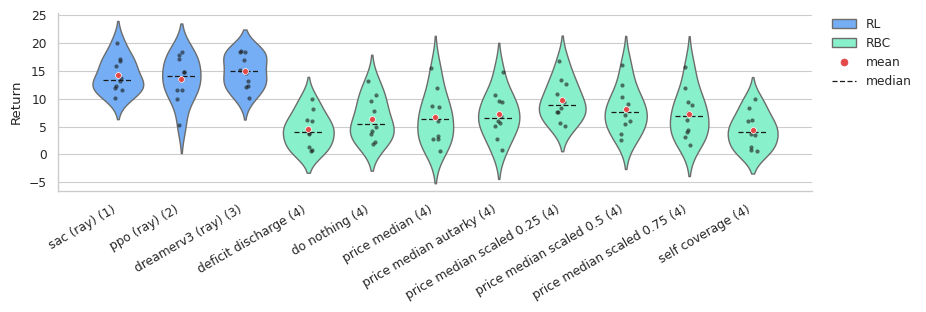

In [33]:
violin_for_metric("total_reward")

In [34]:
metric_table("total_reward")

,episodes,mean ± std,median
Return,,,
sac (ray) (1),10,14.24 ± 3.07,13.40
ppo (ray) (2),10,13.47 ± 4.03,14.02
dreamerv3 (ray) (3),10,14.94 ± 3.03,14.90
deficit discharge (4),10,4.48 ± 3.12,4.07
do nothing (4),10,6.40 ± 3.77,5.51
price median (4),10,6.68 ± 4.62,6.37
price median autarky (4),10,7.17 ± 4.09,6.49
price median scaled 0.25 (4),10,9.74 ± 3.64,8.88
price median scaled 0.5 (4),10,8.06 ± 4.10,7.60


saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/2_base_bat_rbc_vs_rl/20260811_103651_out_2.pdf  (cum_E_kWh)


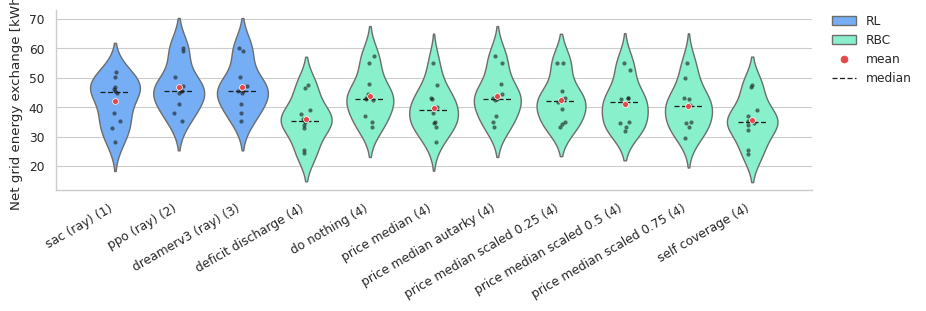

In [35]:
violin_for_metric("cum_E_kWh")

In [36]:
metric_table("cum_E_kWh")

,episodes,mean ± std,median
Net grid energy exchange [kWh],,,
sac (ray) (1),10,42.09 ± 7.89,45.24
ppo (ray) (2),10,46.77 ± 8.04,45.62
dreamerv3 (ray) (3),10,46.77 ± 8.04,45.62
deficit discharge (4),10,35.93 ± 7.58,35.53
do nothing (4),10,43.92 ± 7.99,42.98
price median (4),10,39.80 ± 7.78,39.03
price median autarky (4),10,43.92 ± 7.99,42.98
price median scaled 0.25 (4),10,42.60 ± 7.76,42.29
price median scaled 0.5 (4),10,41.29 ± 7.91,41.98


saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/2_base_bat_rbc_vs_rl/20260811_103651_out_3.pdf  (cum_price_EUR)


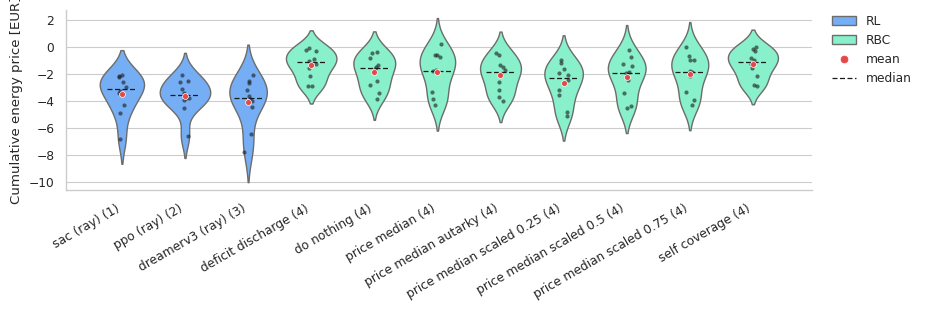

In [37]:
violin_for_metric("cum_price_EUR")

In [38]:
metric_table("cum_price_EUR")

,episodes,mean ± std,median
Cumulative energy price [EUR],,,
sac (ray) (1),10,-3.46 ± 1.48,-3.10
ppo (ray) (2),10,-3.62 ± 1.29,-3.57
dreamerv3 (ray) (3),10,-4.05 ± 1.79,-3.74
deficit discharge (4),10,-1.31 ± 1.04,-1.14
do nothing (4),10,-1.86 ± 1.22,-1.57
price median (4),10,-1.84 ± 1.52,-1.75
price median autarky (4),10,-2.09 ± 1.25,-1.85
price median scaled 0.25 (4),10,-2.70 ± 1.45,-2.28
price median scaled 0.5 (4),10,-2.23 ± 1.47,-1.89


## Missing requested evals

One log line per eval kind that a `SNAPSHOTS` entry requested but for which discovery found no
CSVs (missing or empty `runs/eval_*` directory).

In [39]:
if missing_eval_logs:
    for log_line in missing_eval_logs:
        print(f"WARNING: {log_line}")
else:
    print("All requested eval kinds were found in every snapshot.")